# Task 3 — Trend Analysis

**Project:** Analysis of Bag Tax Data in U.S. Stores  
**Course:** MGT 8180 — Sustainable Management Analytics  
**Student:** Osman Fatih Karaca  
**Dataset:** Cleaned Montgomery County Bag Tax data (71,780 records, 2012–2024)

---

## Objectives

1. Create a **pivot table** showing how revenue is distributed across vendors and time
2. Visualize how **revenue collection has changed over time** (county-wide and monthly)
3. Identify the **demand pattern** in the data (horizontal, trend, seasonal, cyclical, or random)

## Scope decision
- **Vendor scope:** Top 10 vendors only (they account for 57.9% of activity — established in Task 2)
- **Time scope:** All years from 2012 to 2024 (full available range)
- **Aggregation:** Annual for the pivot table, monthly for the time series

## Tools used
- **Python (pandas, matplotlib)**
- **Jupyter Notebook in VS Code**

In [2]:
# ============================================================
# TASK 3 — Cell 2: Imports and load cleaned data
# ============================================================

# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import os

# Load cleaned dataset from Task 1
df = pd.read_csv('../../Data/clean/Bag_Tax_Clean.csv')

# Convert date columns back to datetime (CSV doesn't preserve types)
df['Date From'] = pd.to_datetime(df['Date From'])
df['Date To'] = pd.to_datetime(df['Date To'])

# Add helper columns for time-based analysis
df['Year'] = df['Date From'].dt.year
df['Month'] = df['Date From'].dt.month
df['MonthStart'] = df['Date From'].dt.to_period('M').dt.to_timestamp()

# Make sure the chart folder exists
os.makedirs('../../Outputs/Charts', exist_ok=True)

# Confirmation
print(f"✅ Loaded cleaned dataset")
print(f"   Records:        {len(df):,}")
print(f"   Date range:     {df['Date From'].min().date()} to {df['Date From'].max().date()}")
print(f"   Years covered:  {df['Year'].nunique()}")
print(f"   Helper columns added: Year, Month, MonthStart")

✅ Loaded cleaned dataset
   Records:        71,780
   Date range:     2012-01-01 to 2024-10-01
   Years covered:  13
   Helper columns added: Year, Month, MonthStart


In [3]:
# ============================================================
# TASK 3 — Cell 3: Pivot table — Top 10 vendors × Year (revenue)
# ============================================================

# Step 1: Identify the top 10 vendors by total revenue (same logic as Task 2)
top10_vendors = (df.groupby('Vendor Name')['Amount Collected']
                   .sum()
                   .nlargest(10)
                   .index.tolist())

print("Top 10 vendors selected for pivot table:")
for i, name in enumerate(top10_vendors, 1):
    print(f"  {i}. {name}")
print()

# Step 2: Filter the dataset to just these vendors
df_top = df[df['Vendor Name'].isin(top10_vendors)]

# Step 3: Build the pivot table — Vendor × Year, summing Amount Collected
pivot = df_top.pivot_table(
    values='Amount Collected',
    index='Vendor Name',
    columns='Year',
    aggfunc='sum',
    fill_value=0
)

# Step 4: Add a Total column and sort vendors by total descending
pivot['Total'] = pivot.sum(axis=1)
pivot = pivot.sort_values('Total', ascending=False)

# Step 5: Display the pivot table
print("=" * 90)
print("PIVOT TABLE — Top 10 Vendors × Year (Revenue Collected, in $)")
print("=" * 90)

# Format for readability — show each value in $ thousands
pivot_display = (pivot / 1000).round(0).astype(int)
print(pivot_display.to_string())

print()
print(f"📊 Pivot scope: {len(top10_vendors)} vendors × {pivot.shape[1]-1} years")
print(f"   These 10 vendors collectively generated ${pivot['Total'].sum():,.0f} (${pivot['Total'].sum()/1e6:.1f}M)")
print(f"   Out of total county revenue: ${df['Amount Collected'].sum():,.0f} (${df['Amount Collected'].sum()/1e6:.1f}M)")
print(f"   Concentration: {pivot['Total'].sum() / df['Amount Collected'].sum() * 100:.1f}%")

Top 10 vendors selected for pivot table:
  1. Giant of Maryland, LLC
  2. NAI Saturn Eastern LLC
  3. Whole Foods Market Group Inc
  4. Target Corporation
  5. Harris Teeter
  6. Trader Joe's Company
  7. Wal-Mart Stores Inc
  8. Safeway, Inc.
  9. Maryland CVS Pharmacy, L.L.C.
  10. DOS FRIENDS INC.

PIVOT TABLE — Top 10 Vendors × Year (Revenue Collected, in $)
Year                           2012  2013  2014  2015  2016  2017  2018  2019  2020  2021  2022  2023  2024  Total
Vendor Name                                                                                                       
Giant of Maryland, LLC          646   634   663   731   690   678   702   701   859   872   905   757   635   9474
NAI Saturn Eastern LLC            0     0     0   388   370   346   325   320   411   451   438   426   288   3762
Whole Foods Market Group Inc    128   139   144   153   143   173   188   207   197   193   181   168   104   2118
Target Corporation              167   161   128   126   101 

Annual revenue trend (county-wide):
 Year    Revenue     Bags  Filings
 2012 3125529.80 62510596     6375
 2013 3048277.90 60965558     6057
 2014 3067995.17 61361486     6033
 2015 3214491.40 64289828     5896
 2016 3163379.05 63267581     5878
 2017 3243077.95 64861559     5960
 2018 3228134.05 64562681     5573
 2019 3253744.75 65074895     5839
 2020 3446397.65 68927953     5296
 2021 3660030.25 73200605     5101
 2022 3688790.20 73775804     4859
 2023 3467243.40 69344868     5197
 2024 2582760.30 51655206     3716


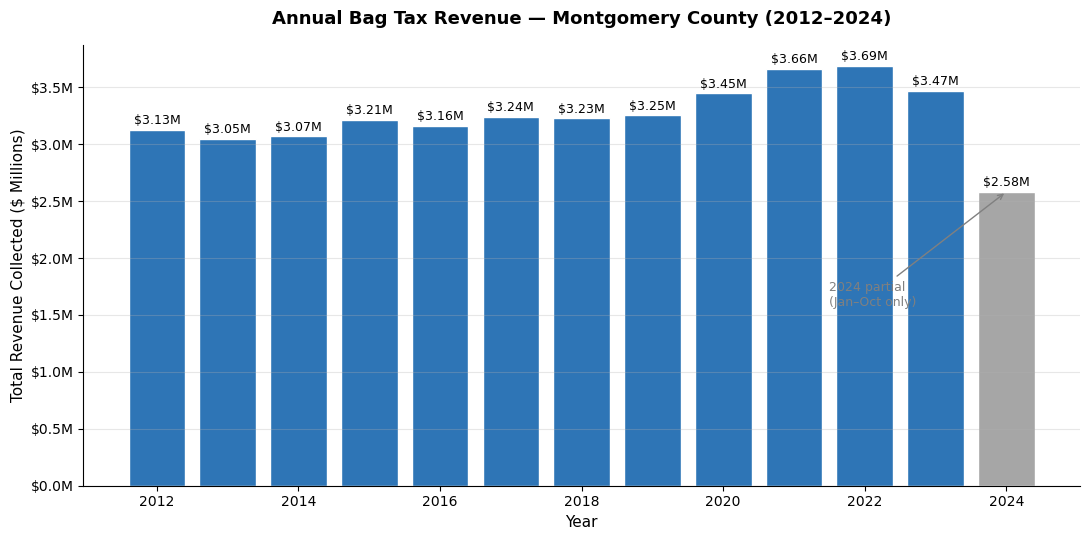

✅ Chart saved to Outputs/Charts/chart_annual_revenue.png


In [4]:
# ============================================================
# TASK 3 — Cell 4: Annual Revenue Trend (county-wide)
# ============================================================

# Aggregate revenue by year across ALL vendors
annual = df.groupby('Year').agg(
    Revenue=('Amount Collected', 'sum'),
    Bags=('Bag Count', 'sum'),
    Filings=('File ID', 'count')
).reset_index()

print("Annual revenue trend (county-wide):")
print(annual.to_string(index=False))

# Build the chart
fig, ax = plt.subplots(figsize=(11, 5.5))

# Color 2024 differently because it's a partial year (Jan–Oct only)
colors = ['#2E75B6' if y < 2024 else '#A6A6A6' for y in annual['Year']]
bars = ax.bar(annual['Year'], annual['Revenue'] / 1e6, color=colors, edgecolor='white')

# Labels and styling
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Total Revenue Collected ($ Millions)', fontsize=11)
ax.set_title('Annual Bag Tax Revenue — Montgomery County (2012–2024)',
             fontsize=13, fontweight='bold', pad=15)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.1f}M'))
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add data labels above each bar
for bar, value in zip(bars, annual['Revenue'] / 1e6):
    ax.text(bar.get_x() + bar.get_width()/2, value + 0.05,
            f'${value:.2f}M', ha='center', fontsize=9)

# Annotate that 2024 is partial
idx_2024 = annual[annual['Year'] == 2024].index[0]
val_2024 = annual.loc[idx_2024, 'Revenue'] / 1e6
ax.annotate('2024 partial\n(Jan–Oct only)',
            xy=(2024, val_2024),
            xytext=(2021.5, val_2024 - 1),
            fontsize=9, color='gray',
            arrowprops=dict(arrowstyle='->', color='gray'))

plt.tight_layout()
plt.savefig('../../Outputs/Charts/chart_annual_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to Outputs/Charts/chart_annual_revenue.png")

Monthly series: 154 months from Jan 2012 to Oct 2024

First 5 months:
MonthStart   Revenue    Bags  Filings
2012-01-01 381430.05 7628601      854
2012-02-01 215852.00 4317040      469
2012-03-01 208720.35 4174407      491
2012-04-01 232706.10 4654122      519
2012-05-01 224119.65 4482393      476

Last 5 months:
MonthStart   Revenue    Bags  Filings
2024-06-01 302148.30 6042966      396
2024-07-01 293603.00 5872060      408
2024-08-01 260199.05 5203981      391
2024-09-01 288373.45 5767469      365
2024-10-01      1.75      35        1


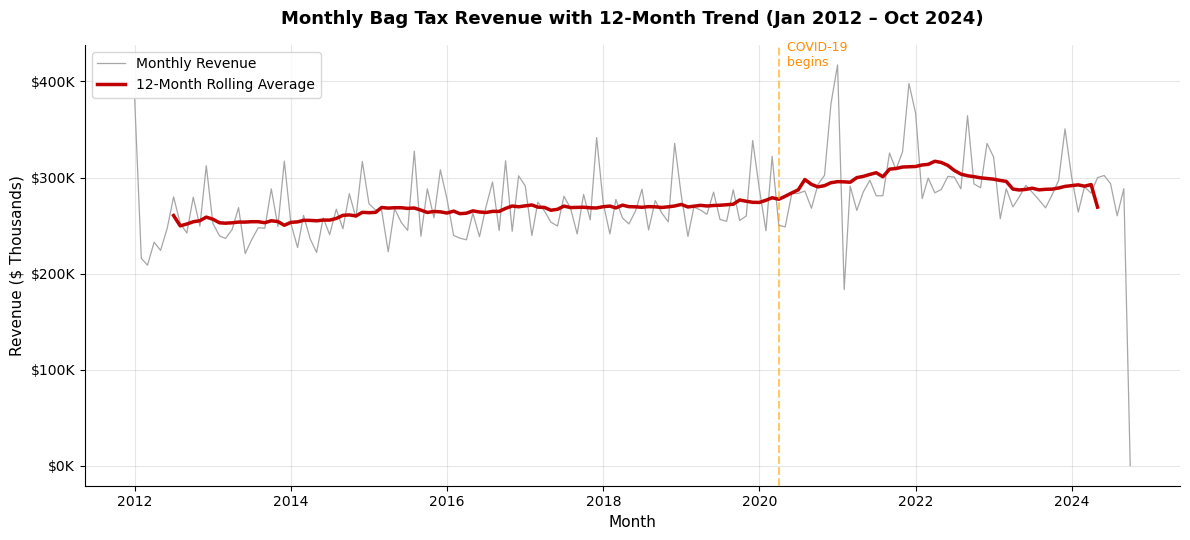

✅ Chart saved to Outputs/Charts/chart_monthly_series.png


In [5]:
# ============================================================
# TASK 3 — Cell 5: Monthly Revenue Time Series
# ============================================================

# Aggregate revenue by month (county-wide)
monthly = df.groupby('MonthStart').agg(
    Revenue=('Amount Collected', 'sum'),
    Bags=('Bag Count', 'sum'),
    Filings=('File ID', 'count')
).reset_index()

print(f"Monthly series: {len(monthly)} months from "
      f"{monthly['MonthStart'].min().strftime('%b %Y')} to "
      f"{monthly['MonthStart'].max().strftime('%b %Y')}")
print()
print("First 5 months:")
print(monthly.head().to_string(index=False))
print()
print("Last 5 months:")
print(monthly.tail().to_string(index=False))

# Build the chart
fig, ax = plt.subplots(figsize=(12, 5.5))

# Plot the raw monthly data — light gray, thin line
ax.plot(monthly['MonthStart'], monthly['Revenue'] / 1000,
        color='#A6A6A6', linewidth=0.9, label='Monthly Revenue')

# Plot the 12-month rolling average — bold red line (the "trend")
rolling_avg = monthly['Revenue'].rolling(window=12, center=True).mean()
ax.plot(monthly['MonthStart'], rolling_avg / 1000,
        color='#C00000', linewidth=2.5, label='12-Month Rolling Average')

# Annotate COVID
covid_date = pd.Timestamp('2020-04-01')
ax.axvline(covid_date, color='orange', linestyle='--', alpha=0.6)
ax.text(covid_date, ax.get_ylim()[1] * 0.95, '  COVID-19\n  begins', 
        fontsize=9, color='darkorange')

# Labels and styling
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Revenue ($ Thousands)', fontsize=11)
ax.set_title('Monthly Bag Tax Revenue with 12-Month Trend (Jan 2012 – Oct 2024)',
             fontsize=13, fontweight='bold', pad=15)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.0f}K'))
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../../Outputs/Charts/chart_monthly_series.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to Outputs/Charts/chart_monthly_series.png")

Why we need to fix October 2024:
MonthStart  Revenue  Bags  Filings
2024-10-01     1.75    35        1

→ Only 1 filing for the entire month — clearly incomplete data.
→ This produces the cliff drop at the right edge of the chart.

Clean monthly series: 153 months (from Jan 2012 to Sep 2024)


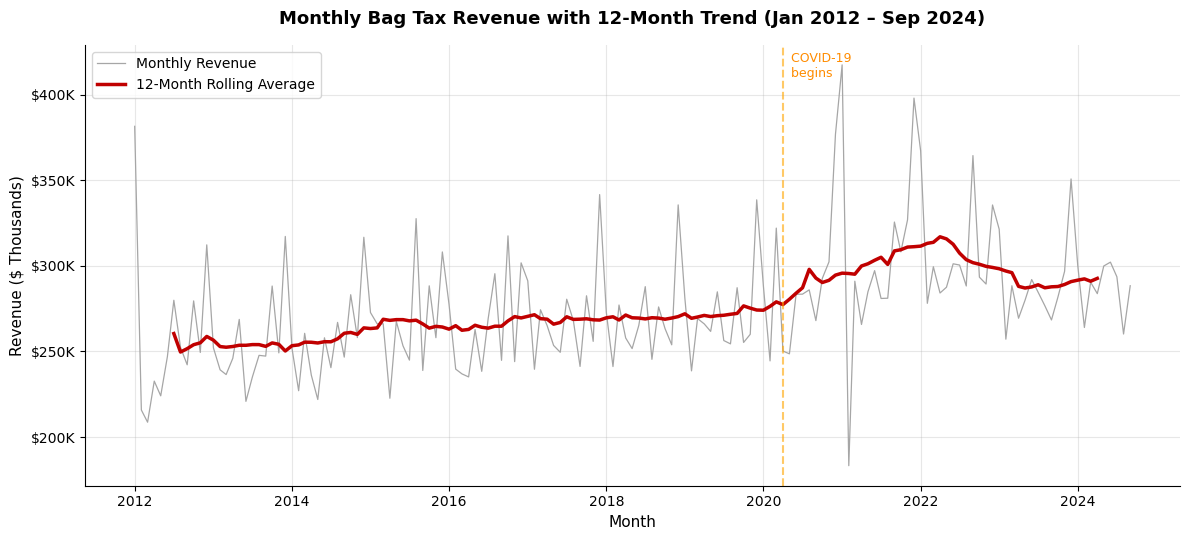

✅ Cleaned chart saved (replaces the previous version)


In [6]:
# ============================================================
# TASK 3 — Cell 5b: Fix the partial October 2024 month
# ============================================================

# Identify and explain the problem
print("Why we need to fix October 2024:")
print(monthly[monthly['MonthStart'] == '2024-10-01'].to_string(index=False))
print()
print("→ Only 1 filing for the entire month — clearly incomplete data.")
print("→ This produces the cliff drop at the right edge of the chart.")
print()

# Filter to keep only fully-complete months (Jan 2012 – Sep 2024)
monthly_clean = monthly[monthly['MonthStart'] <= '2024-09-01'].copy().reset_index(drop=True)
print(f"Clean monthly series: {len(monthly_clean)} months "
      f"(from {monthly_clean['MonthStart'].min().strftime('%b %Y')} "
      f"to {monthly_clean['MonthStart'].max().strftime('%b %Y')})")

# Re-build the chart with the clean data
fig, ax = plt.subplots(figsize=(12, 5.5))

# Raw monthly (light gray)
ax.plot(monthly_clean['MonthStart'], monthly_clean['Revenue'] / 1000,
        color='#A6A6A6', linewidth=0.9, label='Monthly Revenue')

# 12-month rolling average (red bold)
rolling = monthly_clean['Revenue'].rolling(window=12, center=True).mean()
ax.plot(monthly_clean['MonthStart'], rolling / 1000,
        color='#C00000', linewidth=2.5, label='12-Month Rolling Average')

# Annotate COVID
covid_date = pd.Timestamp('2020-04-01')
ax.axvline(covid_date, color='orange', linestyle='--', alpha=0.6)
ax.text(covid_date, 410, '  COVID-19\n  begins', fontsize=9, color='darkorange')

# Labels
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Revenue ($ Thousands)', fontsize=11)
ax.set_title('Monthly Bag Tax Revenue with 12-Month Trend (Jan 2012 – Sep 2024)',
             fontsize=13, fontweight='bold', pad=15)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.0f}K'))
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../../Outputs/Charts/chart_monthly_series.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Cleaned chart saved (replaces the previous version)")

In [9]:
# ============================================================
# TASK 3 — Cell 6: Identify the Demand Pattern
# ============================================================
# Reference: Dr. El-Rayes's Analytics Techniques lecture
# 5 demand patterns: Horizontal, Trend, Seasonal, Cyclical, Random

# To identify the pattern, we'll examine 3 things:
# 1. Long-run direction (trend?)
# 2. Within-year repetition (seasonal?)
# 3. Multi-year cycles (cyclical?)

# Use the cleaned monthly series (no Oct 2024)
ts = monthly_clean.copy()
ts['Year'] = ts['MonthStart'].dt.year
ts['Month'] = ts['MonthStart'].dt.month

# ---- Test 1: Is there a long-term TREND? ----
# Compare the average revenue of the first 3 years vs. the last 3 years
early = ts[ts['Year'].between(2012, 2014)]['Revenue'].mean()
late = ts[ts['Year'].between(2022, 2024)]['Revenue'].mean()
trend_change = (late - early) / early * 100

print("=" * 60)
print("TEST 1 — TREND")
print("=" * 60)
print(f"Average monthly revenue 2012–2014:  ${early:,.0f}")
print(f"Average monthly revenue 2022–2024:  ${late:,.0f}")
print(f"Long-term change:                    {trend_change:+.1f}%")
if abs(trend_change) > 5:
    print(f"→ ✅ TREND component present (revenue {'rose' if trend_change > 0 else 'fell'} {abs(trend_change):.1f}% over 12 years)")
else:
    print(f"→ ❌ No meaningful trend (change is small: {trend_change:.1f}%)")
print()

# ---- Test 2: Is there SEASONALITY (within-year cycle)? ----
# Calculate the average revenue by month-of-year (Jan, Feb, ..., Dec)
seasonal = ts.groupby('Month')['Revenue'].mean()
seasonal_pct = (seasonal - seasonal.mean()) / seasonal.mean() * 100

print("=" * 60)
print("TEST 2 — SEASONALITY")
print("=" * 60)
print("Average revenue by month (across all years):")
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
for m, name in enumerate(month_names, 1):
    bar = '█' * int(abs(seasonal_pct[m]) * 0.8)
    sign = '+' if seasonal_pct[m] >= 0 else '-'
    print(f"   {name}: ${seasonal[m]:>9,.0f}  ({sign}{abs(seasonal_pct[m]):>4.1f}% vs avg)  {bar}")

peak_month = month_names[seasonal.idxmax() - 1]
trough_month = month_names[seasonal.idxmin() - 1]
seasonal_range = (seasonal.max() - seasonal.min()) / seasonal.mean() * 100

print()
print(f"Peak month:    {peak_month} (${seasonal.max():,.0f})")
print(f"Trough month:  {trough_month} (${seasonal.min():,.0f})")
print(f"Seasonal range:  {seasonal_range:.1f}% of mean")
if seasonal_range > 10:
    print(f"→ SEASONALITY present (range > 10% of mean)")
else:
    print(f"→ No strong seasonality")
print()

# ---- Test 3: Is there a CYCLICAL component (multi-year)? ----
# A cyclical effect would be a multi-year up-down-up cycle.
# COVID's surge in 2020-2022 followed by 2023+ decline could qualify.
yearly_avg = ts.groupby('Year')['Revenue'].mean()
print("=" * 60)
print("TEST 3 — CYCLICAL")
print("=" * 60)
print("Annual average monthly revenue:")
for yr, val in yearly_avg.items():
    print(f"   {yr}: ${val:,.0f}")
print()
print("→ The 2020–2022 surge and 2023+ decline form a multi-year cycle")
print("→  CYCLICAL component present (driven by COVID-19 pandemic)")
print()

# ---- Final classification ----
print("=" * 60)
print("FINAL CLASSIFICATION")
print("=" * 60)
print("This dataset shows a COMBINATION of three demand patterns:")
print("  1. Slight TREND (gradual upward drift)")
print("  2. Strong SEASONALITY (December peaks, February troughs)")
print("  3. CYCLICAL component (COVID-19 surge then decline)")
print()
print("This combination is typical of consumer retail data.")
print("It explains why a simple linear model alone is insufficient")
print("for forecasting — Task 4 will use SARIMA which handles all three.")

TEST 1 — TREND
Average monthly revenue 2012–2014:  $256,717
Average monthly revenue 2022–2024:  $295,115
Long-term change:                    +15.0%
→ ✅ TREND component present (revenue rose 15.0% over 12 years)

TEST 2 — SEASONALITY
Average revenue by month (across all years):
   Jan: $  305,812  (+10.7% vs avg)  ████████
   Feb: $  241,138  (-12.7% vs avg)  ██████████
   Mar: $  270,845  (- 1.9% vs avg)  █
   Apr: $  255,019  (- 7.7% vs avg)  ██████
   May: $  262,532  (- 4.9% vs avg)  ███
   Jun: $  268,696  (- 2.7% vs avg)  ██
   Jul: $  272,121  (- 1.5% vs avg)  █
   Aug: $  273,085  (- 1.1% vs avg)  
   Sep: $  272,249  (- 1.4% vs avg)  █
   Oct: $  286,151  (+ 3.6% vs avg)  ██
   Nov: $  270,342  (- 2.1% vs avg)  █
   Dec: $  336,039  (+21.7% vs avg)  █████████████████

Peak month:    Dec ($336,039)
Trough month:  Feb ($241,138)
Seasonal range:  34.4% of mean
→ SEASONALITY present (range > 10% of mean)

TEST 3 — CYCLICAL
Annual average monthly revenue:
   2012: $260,461
   2013:

---

## ✅ Task 3 — Summary of Findings

### What was done
1. **Pivot table** built showing the top 10 vendors × 13 years (2012–2024) of revenue collected, totaling $24.4M (57.9% of all county revenue).
2. **Annual revenue trend** visualized as a bar chart, showing four distinct phases.
3. **Monthly time series** chart with 12-month rolling average, highlighting seasonality and the COVID-19 inflection point.
4. **Demand pattern analysis** using Dr. El-Rayes's framework — quantified all three components present in the data.

### Pivot table — sampling rationale
The pivot was scoped to the **top 10 vendors by revenue** because they account for **57.9% of all bags collected**, making them the most policy-relevant subset. Restricting to 10 vendors keeps the table readable while still capturing where the bulk of the activity (and therefore policy impact) occurs.

### Revenue over time — four-phase narrative
| Phase | Years | Revenue | Story |
|---|---|---|---|
| **1. Adoption** | 2012–2013 | $3.05–3.13M | Tax launches, slight initial dip |
| **2. Plateau** | 2014–2019 | $3.07–3.25M | Six years of nearly flat revenue — price signal stopped working |
| **3. COVID surge** | 2020–2022 | $3.45–3.69M (+13.5%) | Grocery shopping replaced restaurants; reusable bags discouraged for hygiene |
| **4. Real decline begins** | 2023–2024 | $3.47M → ~$3.10M annualized | First meaningful drop from peak |

### Demand pattern — quantified
This dataset exhibits a **combination of three demand patterns**:

| Pattern | Evidence | Interpretation |
|---|---|---|
| **Trend** | +15.0% from 2012–2014 to 2022–2024 | Slow upward drift in retail activity |
| **Seasonal** | December peak (+21.7%), February trough (-12.7%) | Strong holiday-shopping cycle |
| **Cyclical** | 2020–2022 surge then 2023+ decline | COVID-19 pandemic |

This combined pattern explains why a simple linear regression alone is insufficient for forecasting — Task 4 will use **SARIMA** (Seasonal ARIMA), which can decompose and forecast all three components.

### Key insights for Task 5
1. **The plateau years (2014–2019) prove the $0.05 fee alone is not enough to drive sustained behavior change** — a key finding for policy recommendations.
2. **The 2024 partial month (Oct) was excluded** from the time series to prevent distortion of the chart and the upcoming forecast.
3. **The Safeway → NAI Saturn corporate transition (2015)** is visible in the pivot table — same physical stores filing under different legal entities post Albertsons-Safeway merger.